### 1. Import Libraries and Load Data

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re
import nltk
import ast

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Load IMDb dataset
import kagglehub

# Load the dataset from a local CSV file
dataset_path = "imdb_with_emotions.csv"  # Update with the correct path if needed
df = pd.read_csv(dataset_path)

# Display the first few rows of the dataset
print(df.head())

# Convert the 'emotions' column from string format to a dictionary
df['emotions'] = df['emotions'].apply(ast.literal_eval)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                      cleaned_review sentiment  \
0  one reviewer mentioned watching oz episode hoo...  positive   
1  wonderful little production filming technique ...  positive   
2  thought wonderful way spend time hot summer we...  positive   
3  basically family little boy jake think zombie ...  negative   
4  petter mattei love time money visually stunnin...  positive   

                                            emotions  
0  {'fear': 0.9398821592330933, 'anger': 0.028225...  
1  {'joy': 0.9506715536117554, 'fear': 0.02154896...  
2  {'joy': 0.9554997086524963, 'surprise': 0.0173...  
3  {'sadness': 0.5102293491363525, 'surprise': 0....  
4  {'joy': 0.9587359428405762, 'surprise': 0.0266...  




### 4. Data Preparation for Multi-Emotion Classification



In [4]:
# Convert emotions into binary labels
emotion_labels = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
for label in emotion_labels:
    df[label] = df['emotions'].apply(lambda x: x.get(label, 0))

# Display the first few rows of the dataset with binary emotion labels
print(df[['cleaned_review'] + emotion_labels].head())

# Display first rows to verify
print(df.head())

                                      cleaned_review     anger   disgust  \
0  one reviewer mentioned watching oz episode hoo...  0.028225  0.000512   
1  wonderful little production filming technique ...  0.001326  0.000498   
2  thought wonderful way spend time hot summer we...  0.003789  0.000570   
3  basically family little boy jake think zombie ...  0.028454  0.001045   
4  petter mattei love time money visually stunnin...  0.001782  0.000299   

       fear       joy   neutral   sadness  surprise  
0  0.939882  0.012503  0.002846  0.008678  0.007353  
1  0.021549  0.950672  0.014455  0.005725  0.005775  
2  0.000415  0.955500  0.015301  0.007102  0.017323  
3  0.018261  0.180023  0.074427  0.510229  0.187561  
4  0.000749  0.958736  0.007954  0.003795  0.026684  
                                      cleaned_review sentiment  \
0  one reviewer mentioned watching oz episode hoo...  positive   
1  wonderful little production filming technique ...  positive   
2  thought wonderful 



### 5. Data Visualization

#### 5.1 Emotion Distribution



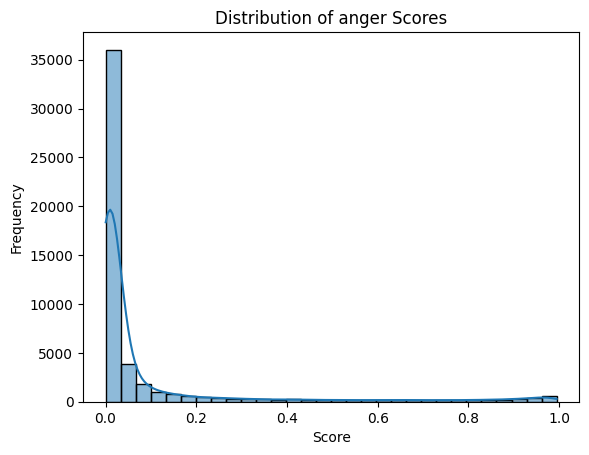

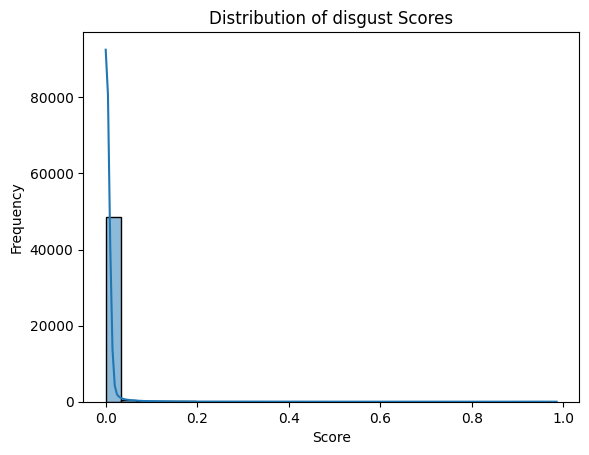

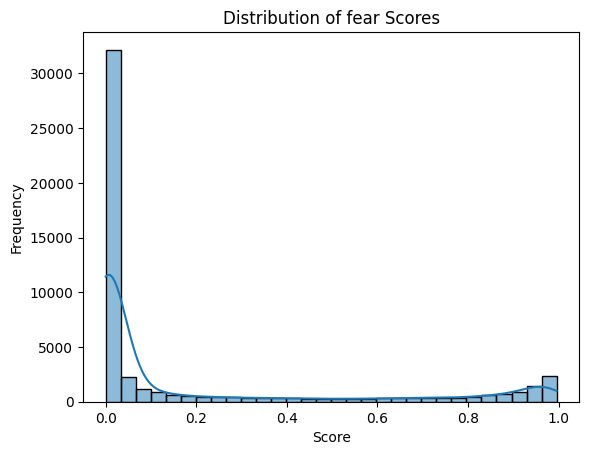

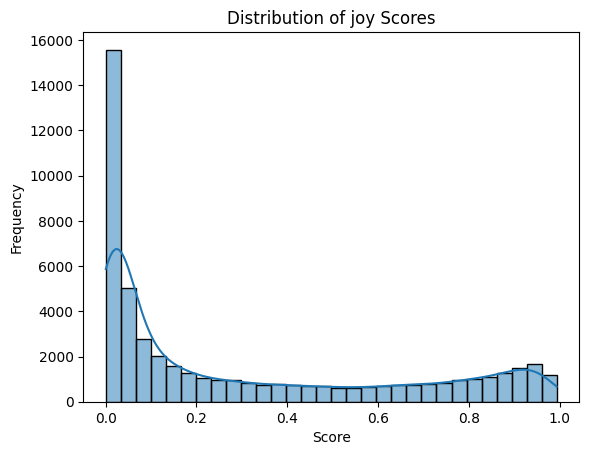

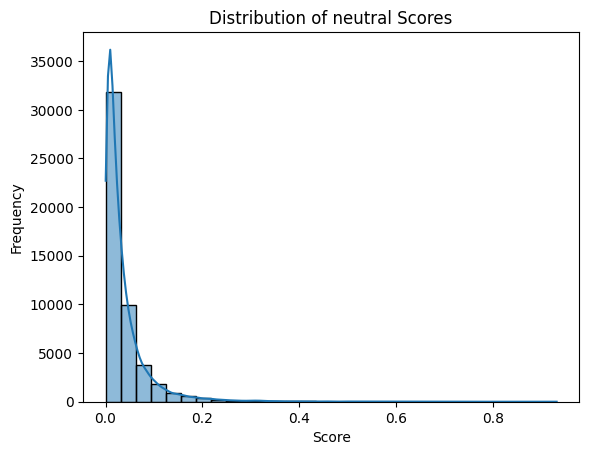

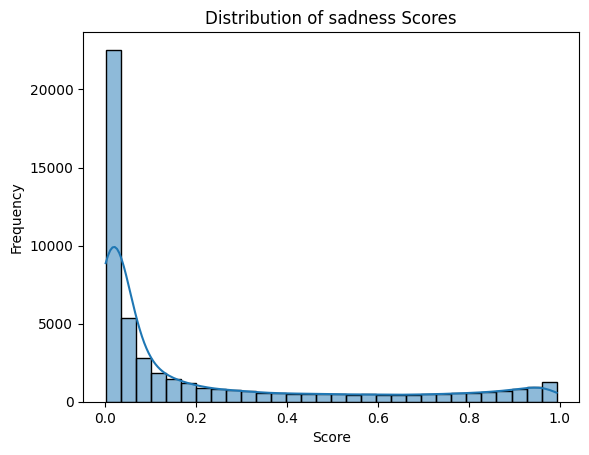

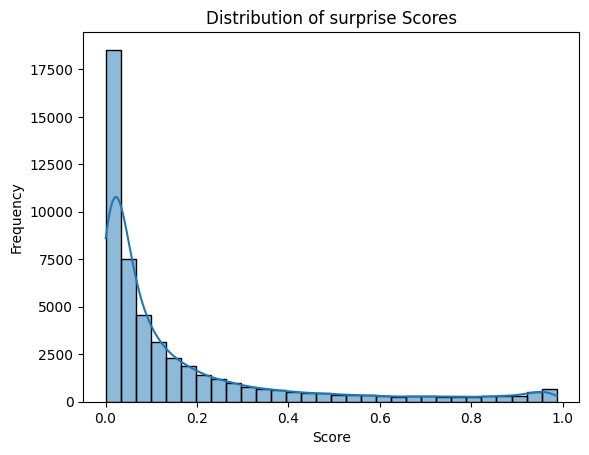

In [5]:
# Visualize emotion distribution
for label in emotion_labels:
    sns.histplot(df[label], kde=True, bins=30)
    plt.title(f'Distribution of {label} Scores')
    plt.xlabel('Score')
    plt.ylabel('Frequency')
    plt.show()

#### 5.2. Test for the amount of emotion scores that are higher or equal to 0.7

In [6]:
# Count rows where each emotion is >= 0.7
emotion_counts = {label: (df[label] >= 0.7).sum() for label in emotion_labels}

# Print partial results
for emotion, count in emotion_counts.items():
    print(f"Rows with {emotion} >= 0.7: {count}")

# Compute the total sum
total_sum = sum(emotion_counts.values())
print(f"Total sum of all rows meeting criteria: {total_sum}")

Rows with anger >= 0.7: 2335
Rows with disgust >= 0.7: 133
Rows with fear >= 0.7: 7442
Rows with joy >= 0.7: 10159
Rows with neutral >= 0.7: 19
Rows with sadness >= 0.7: 6333
Rows with surprise >= 0.7: 3077
Total sum of all rows meeting criteria: 29498


In [7]:
# Count rows where each emotion is >= 0.65
emotion_counts = {label: (df[label] >= 0.65).sum() for label in emotion_labels}

# Print partial results
for emotion, count in emotion_counts.items():
    print(f"Rows with {emotion} >= 0.65: {count}")

# Compute the total sum
total_sum = sum(emotion_counts.values())
print(f"Total sum of all rows meeting criteria: {total_sum}")

Rows with anger >= 0.65: 2600
Rows with disgust >= 0.65: 159
Rows with fear >= 0.65: 7945
Rows with joy >= 0.65: 11315
Rows with neutral >= 0.65: 28
Rows with sadness >= 0.65: 7030
Rows with surprise >= 0.65: 3483
Total sum of all rows meeting criteria: 32560




#### 5.3 Correlation Matrix



/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


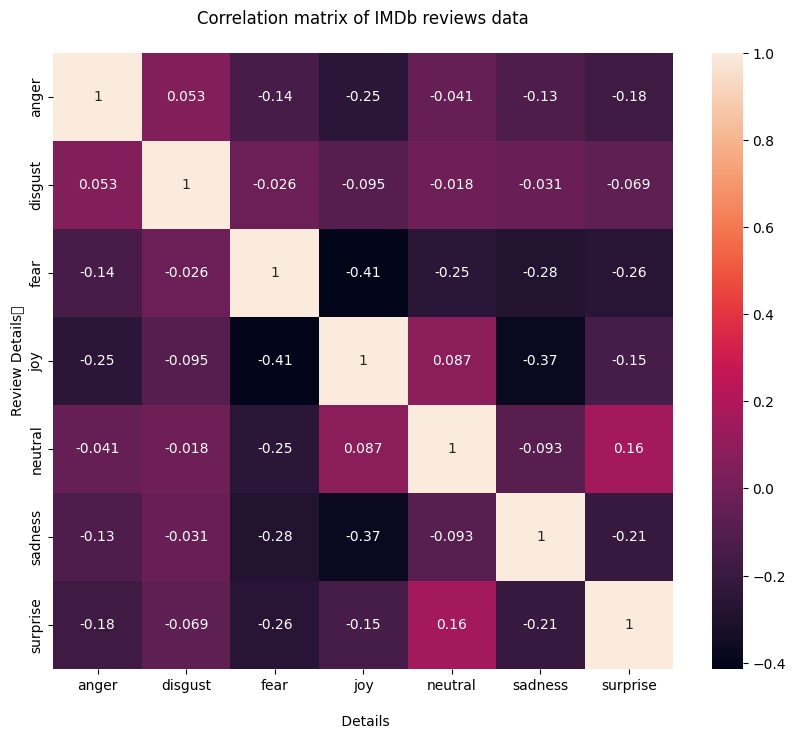

In [8]:
# Display correlation matrix
a4_dims = (10, 8)
fig, ax = plt.subplots(figsize=a4_dims)

hm = sns.heatmap(ax=ax, data=df[emotion_labels].corr(), annot=True)
hm.set(xlabel='\n Details', ylabel='Review Details\t', title="Correlation matrix of IMDb reviews data\n")

plt.show()



### 6. Text Analysis

#### 6.1 Word Frequency by Emotion



[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Most common words in anger reviews:
[('movie', 4309), ('film', 4146), ('one', 2646), ('like', 2043), ('character', 1490), ('time', 1417), ('would', 1360), ('even', 1270), ('get', 1254), ('make', 1223), ('people', 1192), ('good', 1168), ('story', 1071), ('see', 1058), ('scene', 962), ('show', 928), ('way', 927), ('really', 925), ('well', 893), ('bad', 872)]


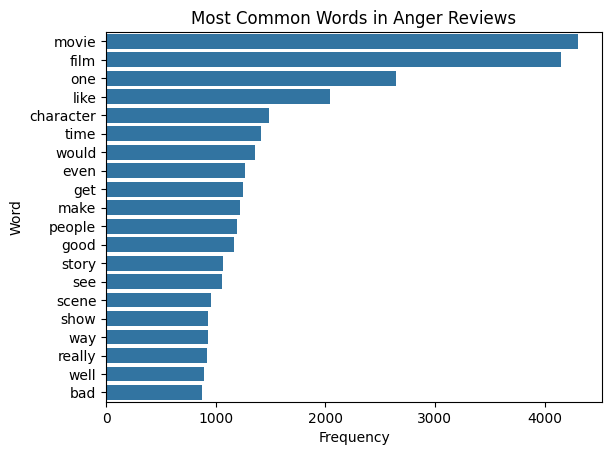

Most common words in disgust reviews:
[('movie', 241), ('film', 149), ('disgusting', 107), ('one', 99), ('like', 78), ('time', 64), ('would', 59), ('show', 58), ('good', 56), ('ever', 54), ('see', 51), ('bad', 49), ('people', 48), ('character', 48), ('seen', 46), ('really', 45), ('even', 45), ('make', 41), ('watch', 38), ('scene', 36)]


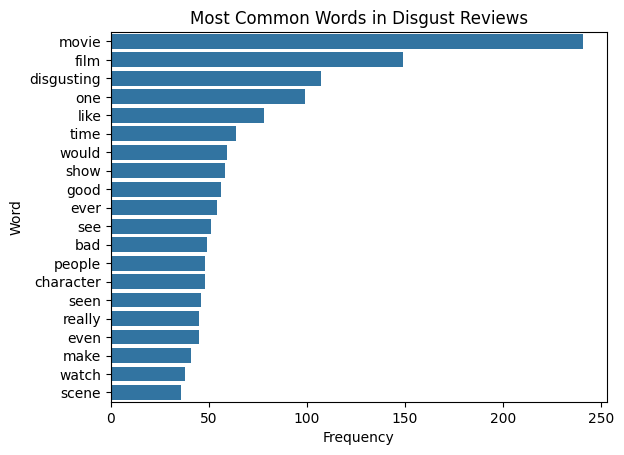

Most common words in fear reviews:
[('film', 16727), ('movie', 16149), ('one', 9565), ('like', 6898), ('horror', 5479), ('time', 4888), ('even', 4464), ('good', 4384), ('get', 4320), ('make', 4312), ('character', 4115), ('scene', 4023), ('story', 3920), ('would', 3898), ('see', 3817), ('really', 3722), ('well', 3347), ('bad', 3290), ('people', 3135), ('thing', 3010)]


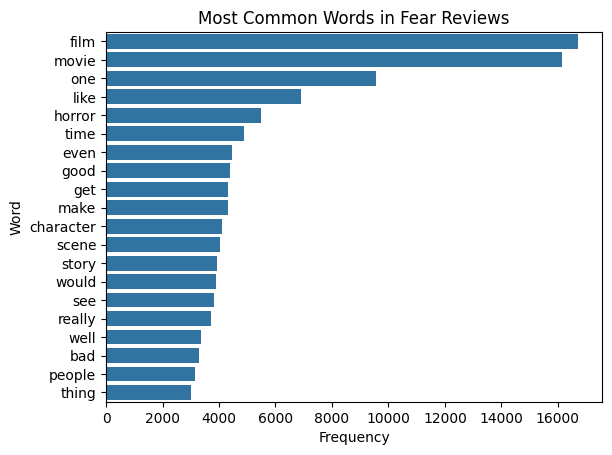

Most common words in joy reviews:
[('movie', 19468), ('film', 17480), ('one', 10060), ('like', 7103), ('good', 6314), ('time', 6009), ('character', 5699), ('great', 5084), ('story', 4925), ('well', 4782), ('see', 4600), ('make', 4339), ('really', 4191), ('get', 4172), ('would', 3945), ('show', 3795), ('scene', 3788), ('even', 3716), ('also', 3694), ('much', 3563)]


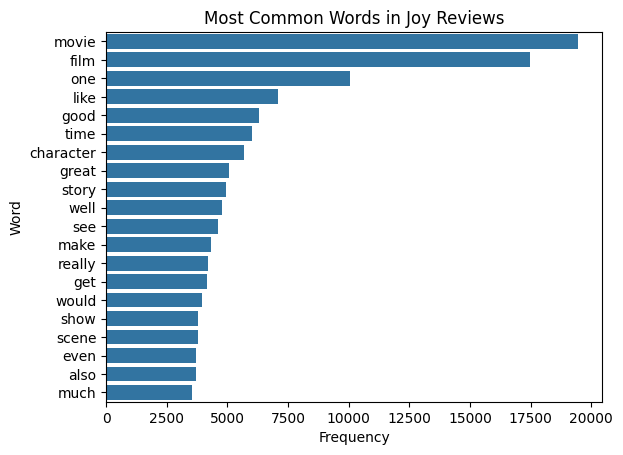

Most common words in neutral reviews:
[('movie', 12), ('one', 9), ('like', 6), ('watch', 5), ('good', 5), ('must', 4), ('please', 4), ('e', 4), ('mail', 4), ('even', 4), ('bad', 4), ('get', 4), ('anything', 3), ('still', 3), ('remember', 3), ('comment', 3), ('original', 3), ('rent', 3), ('time', 3), ('acting', 3)]


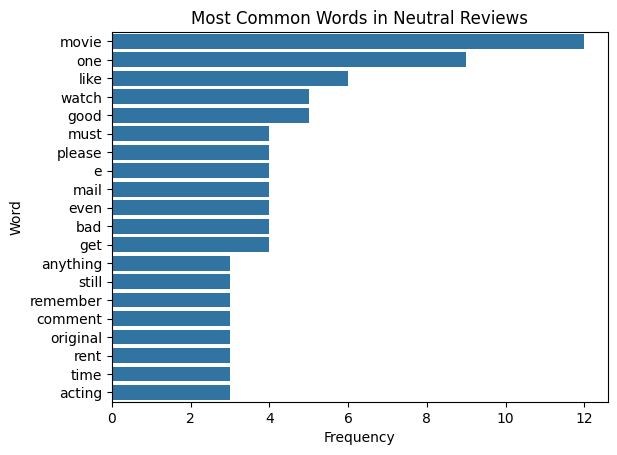

Most common words in sadness reviews:
[('movie', 13091), ('film', 11798), ('one', 6760), ('like', 5125), ('time', 3961), ('character', 3764), ('good', 3603), ('story', 3332), ('even', 3310), ('really', 3070), ('would', 2991), ('see', 2975), ('get', 2951), ('make', 2928), ('bad', 2693), ('much', 2524), ('life', 2498), ('scene', 2495), ('well', 2381), ('people', 2244)]


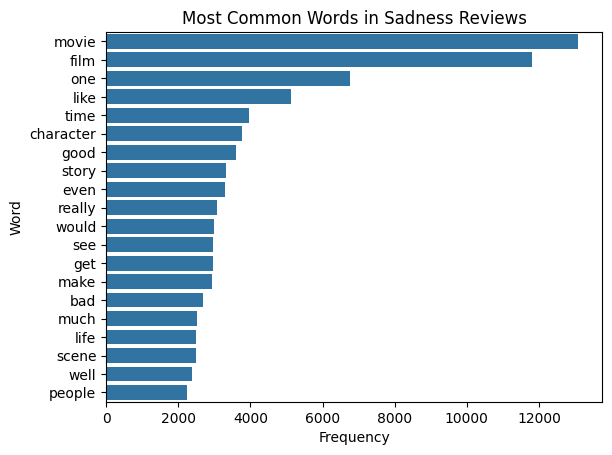

Most common words in surprise reviews:
[('movie', 6998), ('film', 5734), ('one', 3230), ('like', 2572), ('time', 1960), ('good', 1909), ('see', 1747), ('character', 1736), ('would', 1714), ('really', 1705), ('story', 1625), ('even', 1528), ('get', 1415), ('well', 1363), ('make', 1357), ('scene', 1289), ('much', 1276), ('people', 1238), ('first', 1226), ('surprised', 1164)]


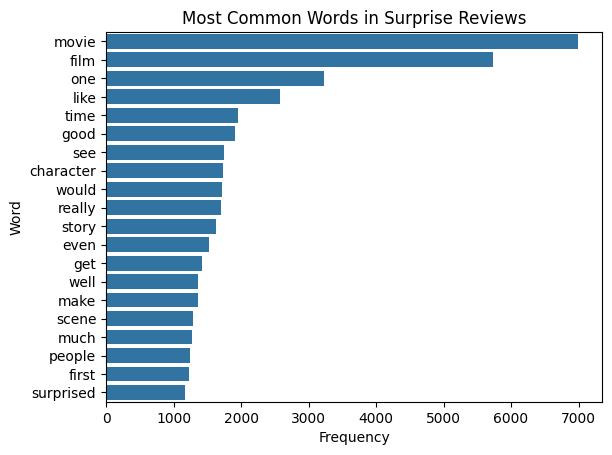

In [9]:
from collections import Counter
import nltk

nltk.download('punkt_tab')

# Tokenize reviews
df['tokens'] = df['cleaned_review'].apply(word_tokenize)

# Count word frequency by emotion
for label in emotion_labels:
    words = df[df[label] > 0.7]['tokens'].explode()
    word_freq = Counter(words)

    # Display the 20 most common words for each emotion
    print(f"Most common words in {label} reviews:")
    print(word_freq.most_common(20))

    # Visualize most common words for each emotion
    common_words = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Frequency'])
    sns.barplot(x='Frequency', y='Word', data=common_words)
    plt.title(f'Most Common Words in {label.capitalize()} Reviews')
    plt.show()



#### 6.2 Word Cloud Generation



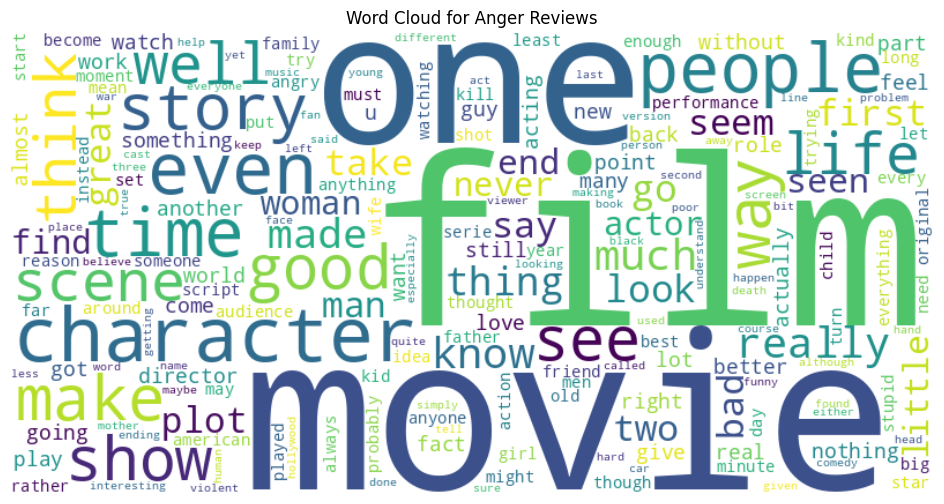

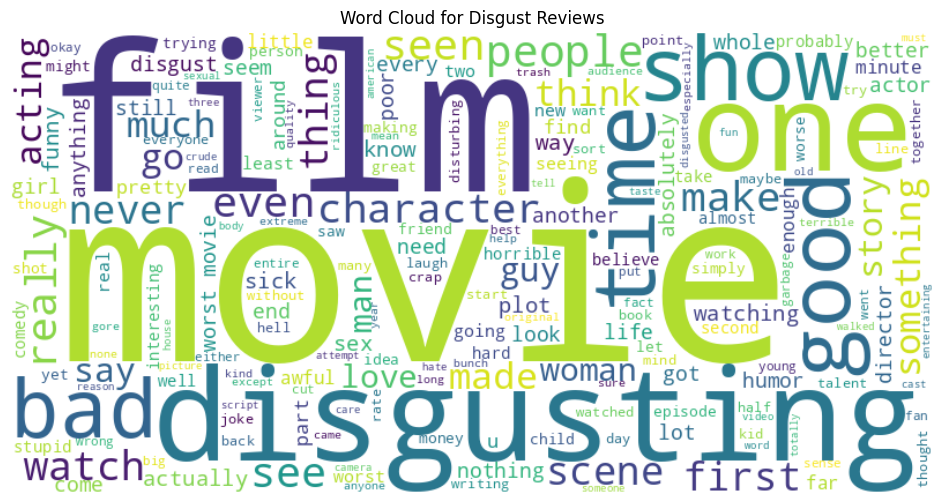

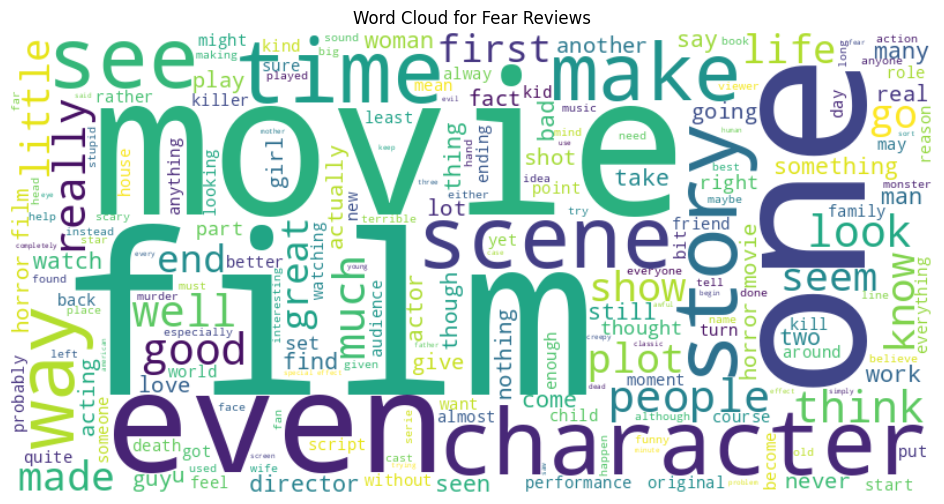

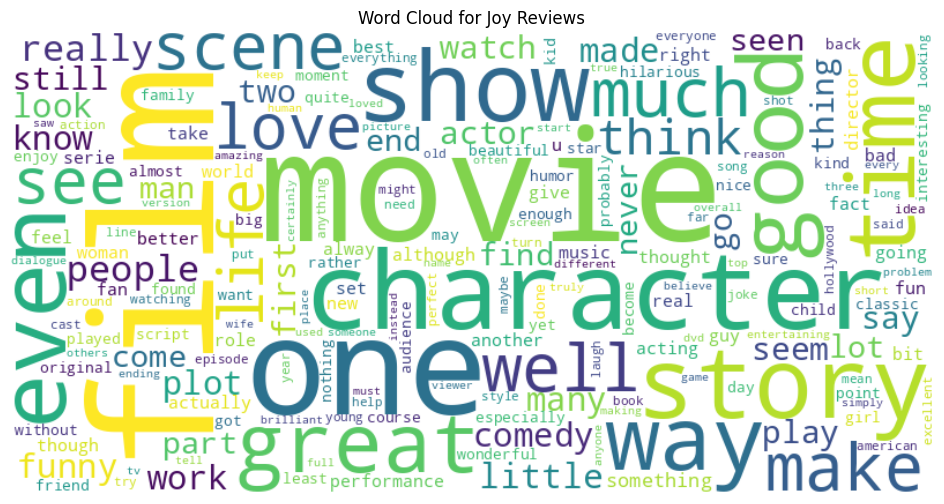

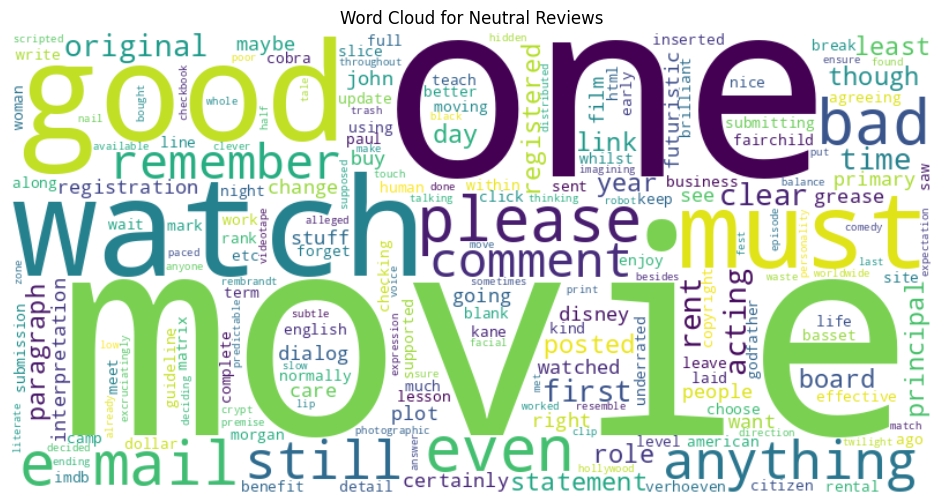

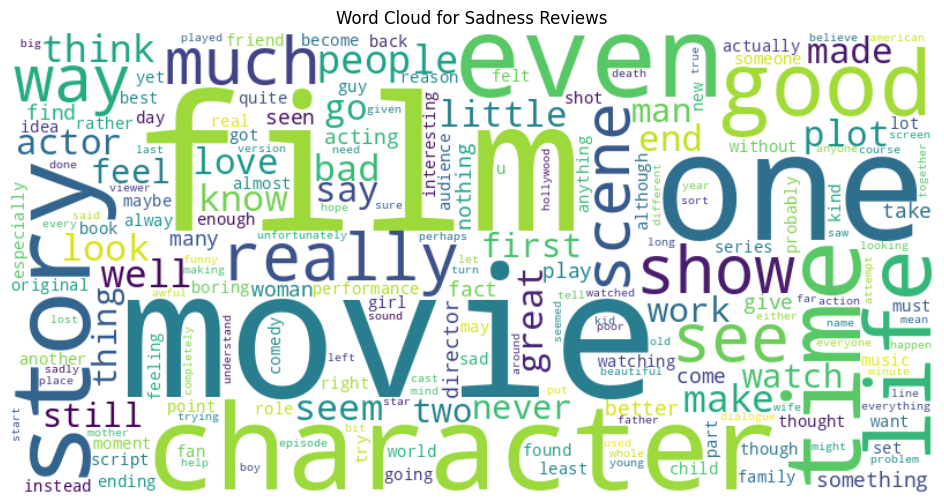

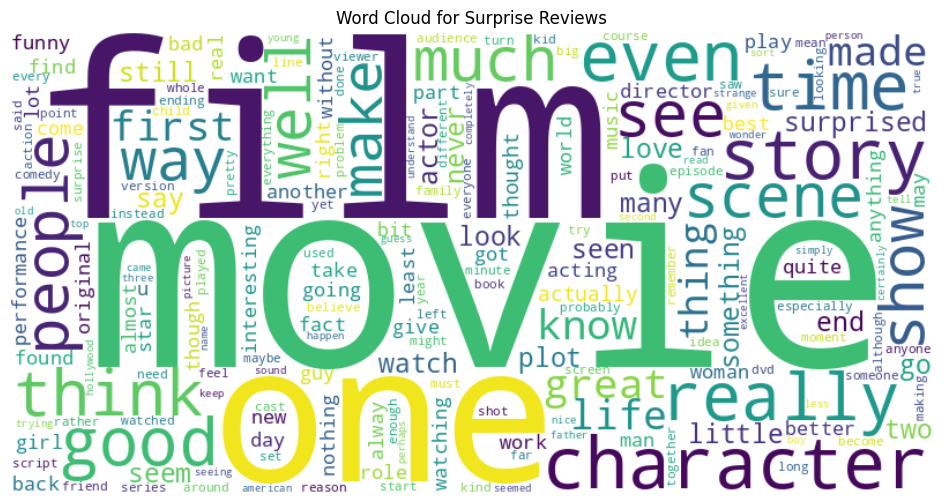

In [10]:
from wordcloud import WordCloud

# Generate word clouds by emotion
for label in emotion_labels:
    text = ' '.join(df[df[label] > 0.7]['cleaned_review'])

    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for {label.capitalize()} Reviews')
    plt.axis('off')
    plt.show()

### 7. Création de l'ensemble de training et de l'ensemble de test

In [11]:
!pip install tensorflow

In [12]:
# Import additional required libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, LSTM, Dense
import numpy as np
from collections import Counter

In [13]:
# Convert emotions dictionary to single label
def get_dominant_emotion(emotions_dict):
    return max(eval(str(emotions_dict)).items(), key=lambda x: x[1])[0]

# Add dominant emotion column
df['dominant_emotion'] = df['emotions'].apply(get_dominant_emotion)

# Encode dominant emotions into numbers
label_encoder = LabelEncoder()
df['dominant_emotion_num'] = label_encoder.fit_transform(df['dominant_emotion'])

# Normalize values between 0 and 1
#df['dominant_emotion_num'] = df['dominant_emotion_num'] / (len(label_encoder.classes_) - 1)

# Check transformation
print(df[['dominant_emotion', 'dominant_emotion_num']].head())

# Check some complete lines
print(df.head())

  dominant_emotion  dominant_emotion_num
0             fear                     2
1              joy                     3
2              joy                     3
3          sadness                     5
4              joy                     3
                                      cleaned_review sentiment  \
0  one reviewer mentioned watching oz episode hoo...  positive   
1  wonderful little production filming technique ...  positive   
2  thought wonderful way spend time hot summer we...  positive   
3  basically family little boy jake think zombie ...  negative   
4  petter mattei love time money visually stunnin...  positive   

                                            emotions     anger   disgust  \
0  {'fear': 0.9398821592330933, 'anger': 0.028225...  0.028225  0.000512   
1  {'joy': 0.9506715536117554, 'fear': 0.02154896...  0.001326  0.000498   
2  {'joy': 0.9554997086524963, 'surprise': 0.0173...  0.003789  0.000570   
3  {'sadness': 0.5102293491363525, 'surprise': 0.... 

In [14]:
# Get unique values and their corresponding normalized values
unique_emotions = df[['dominant_emotion', 'dominant_emotion_num']].drop_duplicates().sort_values('dominant_emotion_num')

# Print all possible values
print(unique_emotions)

    dominant_emotion  dominant_emotion_num
17             anger                     0
167          disgust                     1
0               fear                     2
1                joy                     3
132          neutral                     4
3            sadness                     5
15          surprise                     6


In [15]:
# Get top words per emotion
top_words_per_emotion = {}

for emotion in df['dominant_emotion'].unique():
    reviews = df[df['dominant_emotion'] == emotion]['cleaned_review']
    all_words = " ".join(reviews).split()
    word_counts = Counter(all_words)
    top_words = [word for word, count in word_counts.most_common(30)]  # Get top 30 words
    top_words_per_emotion[emotion] = set(top_words)

# Find common words across emotions
common_words = set.intersection(*top_words_per_emotion.values())

print("Common words across emotions:", common_words)

Common words across emotions: {'scene', 'make', 'like', 'film', 'people', 'good', 'one', 'even', 'movie', 'first', 'would', 'made', 'see', 'get', 'thing', 'character', 'time', 'story'}


In [16]:
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sentence_transformers import SentenceTransformer
from collections import defaultdict

# Mapping emotions based on j-hartmann/emotion-english-distilroberta-base
emotion_mapping = {
    "anger": 0,
    "disgust": 1,
    "fear": 2,
    "joy": 3,
    "neutral": 4,
    "sadness": 5,
    "surprise": 6
}

X = df['cleaned_review']
y = df['dominant_emotion_num']

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
print("\nTraining samples:", X_train.shape[0])
print("\nTesting samples:", X_test.shape[0])


Training samples: 40000

Testing samples: 10000


## Feature engineering

In [18]:
# Vectorization (Bag-of-Words & TF-IDF)
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Sentence Embeddings using Transformer
embedder = SentenceTransformer("all-MiniLM-L6-v2")
X_train_embed = embedder.encode(X_train.tolist(), show_progress_bar=True, batch_size=32)
X_test_embed = embedder.encode(X_test.tolist(), show_progress_bar=True, batch_size=32)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling%2Fconfig.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1250 [00:00<?, ?it/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

In [19]:
# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, multi_class="multinomial"),
    "Multinomial NB": MultinomialNB(),
    "Neural networks": MLPClassifier(random_state=42)
}

# Embedding methods
embedding_data = [
    ("Bag-of-Words", X_train_bow, X_test_bow),
    ("TF-IDF", X_train_tfidf, X_test_tfidf),
    ("Sentence Embedding", X_train_embed, X_test_embed)
]

# Store results
results = defaultdict(dict)

In [20]:
# Training and evaluation loop
for emb_name, X_tr, X_te in embedding_data:
    print(f"\n{'-'*40}\nEvaluating {emb_name} features\n{'-'*40}")

    for model_name, model in models.items():

        # Adjust for Sentence Embeddings - MultinomialNB does not support dense features
        if emb_name == "Sentence Embedding" and model_name == "Multinomial NB":
            model = GaussianNB()
            model_name = "Gaussian NB"

        print(f"\nTraining {model_name}...")
        cv_results = cross_validate(model, X_tr, y_train, cv=5, scoring="accuracy", return_train_score=True)
        model.fit(X_tr, y_train)

        # Get predictions and probabilities
        y_pred = model.predict(X_te)
        y_proba = model.predict_proba(X_te) if hasattr(model, "predict_proba") else None  # Store full 7-class distribution

        # Store results
        results[emb_name][model_name] = {
            "cv_mean": np.mean(cv_results["test_score"]),
            "cv_std": np.std(cv_results["test_score"]),
            "test_accuracy": accuracy_score(y_test, y_pred),
            "report": classification_report(y_test, y_pred, output_dict=True),
            "cm": confusion_matrix(y_test, y_pred),
            "y_proba": y_proba,  # Now storing the entire probability vector
            "y_pred": y_pred
        }

print("\nTraining and evaluation completed.")


----------------------------------------
Evaluating Bag-of-Words features
----------------------------------------

Training Logistic Regression...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


Training Multinomial NB...

Training Neural networks...

----------------------------------------
Evaluating TF-IDF features
----------------------------------------

Training Logistic Regression...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


Training Multinomial NB...


...

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


Training Gaussian NB...

Training Neural networks...


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro


Training and evaluation completed.


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


## Transformer model

In [21]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 19.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.5.1+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.5.1+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_syste

In [22]:
from datasets import Dataset, DatasetDict
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, TrainingArguments, Trainer
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Convert data into DataFrames
df_train = pd.DataFrame({'text': X_train, 'label': y_train})
df_test = pd.DataFrame({'text': X_test, 'label': y_test})

# Create Hugging Face dataset
dataset_dict = DatasetDict({
    'train': Dataset.from_pandas(df_train),
    'test': Dataset.from_pandas(df_test)
})

# Load tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [27]:
# Tokenization function
def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=256)

# Apply tokenization
tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)

# Cleanup dataset
tokenized_datasets = tokenized_datasets.remove_columns(["__index_level_0__", "text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")

# Load pre-trained model with 7 labels (not 2)
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=7)

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [28]:
# Training settings
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps",
    eval_steps=500,
    logging_steps=100,
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)

In [29]:
# Define evaluation metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [30]:
# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

# Train Transformer model
print("\nTraining Transformer model...")
trainer.train()


Training Transformer model...


Step,Training Loss,Validation Loss,Accuracy
500,0.933700,0.901295,0.675400
1000,0.877900,0.801387,0.713600
1500,0.780600,0.759544,0.720800
2000,0.761900,0.729884,0.726800
2500,0.735100,0.685806,0.741400
3000,0.496800,0.708995,0.746600
3500,0.482200,0.712837,0.742600
4000,0.468400,0.709332,0.751500
4500,0.495200,0.688577,0.756600
5000,0.438600,0.679168,0.760700


TrainOutput(global_step=5000, training_loss=0.6885093650817871, metrics={'train_runtime': 2810.8993, 'train_samples_per_second': 28.461, 'train_steps_per_second': 1.779, 'total_flos': 5299168419840000.0, 'train_loss': 0.6885093650817871, 'epoch': 2.0})

In [31]:
# Get predictions
test_pred = trainer.predict(tokenized_datasets["test"])
transformer_probs = torch.nn.functional.softmax(torch.Tensor(test_pred.predictions), dim=1).numpy()

# Store results
results["Transformer"] = {
    "DistilBERT": {
        "test_accuracy": accuracy_score(y_test, np.argmax(test_pred.predictions, axis=1)),
        "report": classification_report(y_test, np.argmax(test_pred.predictions, axis=1), output_dict=True),
        "cm": confusion_matrix(y_test, np.argmax(test_pred.predictions, axis=1)),
        "y_proba": transformer_probs,
        "y_pred": np.argmax(test_pred.predictions, axis=1)
    }
}

## Visualization functions

In [50]:
# Mapping dictionary for string values to emotion names
emotion_mapping = {
    '0': 'anger',
    '1': 'disgust',
    '2': 'fear',
    '3': 'joy',
    '4': 'neutral',
    '5': 'sadness',
    '6': 'surprise'
}

def plot_confusion_matrix(cm, classes, model_name, emb_name):
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix - {model_name} ({emb_name})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

def plot_emotion_mapping_table():
    # Create a DataFrame from the mapping dictionary
    df_mapping = pd.DataFrame(list(emotion_mapping.items()), columns=['Class', 'Equivalent Name'])

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.axis('off')  # Hide axes

    # Create table
    table = ax.table(
        cellText=df_mapping.values,  # Values from the DataFrame
        colLabels=df_mapping.columns,  # Column headers
        cellLoc='center',             # Center-align text
        loc='center'                  # Table location
    )

    # Style adjustments
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)  # Scale cell sizes

    plt.title('Emotion Mapping Table')
    plt.show()

def plot_classification_report(report, model_name, emb_name):
    # Convert the report to a DataFrame and process it
    df_report = pd.DataFrame(report).transpose().drop('support', axis=1, errors='ignore')
    df_report = df_report.reset_index().rename(columns={'index': 'Class'})  # Include class names as a column

    # Rename only the specified values in the 'Class' column using the mapping dictionary
    df_report['Class'] = df_report['Class'].map(emotion_mapping).fillna(df_report['Class'])

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis('off')  # Hide axes

    # Create table
    table = ax.table(
        cellText=df_report.round(4).values,  # Rounded values for readability
        colLabels=df_report.columns,         # Column headers
        cellLoc='center',                    # Center-align text
        loc='center'                         # Table location
    )

    # Style adjustments
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)  # Scale cell sizes

    plt.title(f'Classification Report - {model_name} ({emb_name})')
    plt.show()

def plot_roc_curves(results, y_true):
    # Binarize y_true for multiclass problems (One-vs-Rest)
    unique_classes = np.unique(y_true)
    y_bin = label_binarize(y_true, classes=unique_classes)

    plt.figure(figsize=(10, 8))

    for emb_name in results:
        for model_name in results[emb_name]:
            model_data = results[emb_name][model_name]

            if model_data["y_proba"] is not None:
                y_proba = model_data["y_proba"]

                # Handle binary classification
                if y_proba.ndim == 1 or (y_proba.ndim == 2 and y_proba.shape[1] == 2):
                    # For binary classification with shape (n_samples, 2), take the second column
                    if y_proba.ndim == 2 and y_proba.shape[1] == 2:
                        y_proba = y_proba[:, 1]

                    fpr, tpr, _ = roc_curve(y_true, y_proba)
                    roc_auc = auc(fpr, tpr)
                    plt.plot(fpr, tpr, lw=2,
                            label=f'{model_name} ({emb_name}) AUC = {roc_auc:.2f}')

                # Handle multiclass classification
                elif y_proba.ndim == 2:
                    # Calculate micro-average ROC curve and ROC area
                    fpr = dict()
                    tpr = dict()
                    roc_auc = dict()

                    # Calculate ROC curve and ROC area for each class
                    for i, class_name in enumerate(unique_classes):
                        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_proba[:, i])
                        roc_auc[i] = auc(fpr[i], tpr[i])
                        plt.plot(fpr[i], tpr[i], lw=2,
                                label=f'{model_name} ({emb_name}) Class {class_name} '
                                      f'AUC = {roc_auc[i]:.2f}')

    # Add diagonal line
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend(loc="lower right")
    plt.show()

## Generate all visualizations


Generating visualizations...


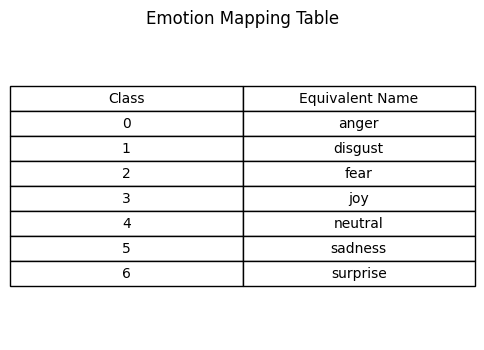

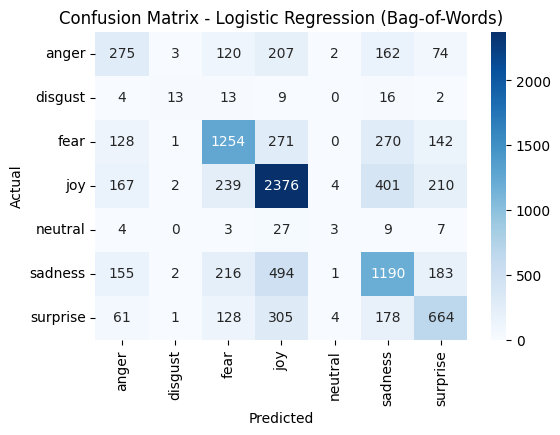

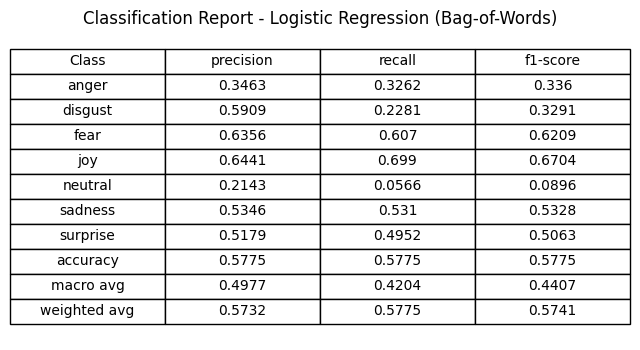

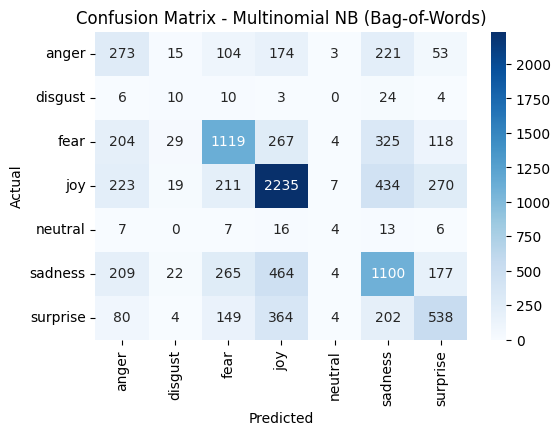

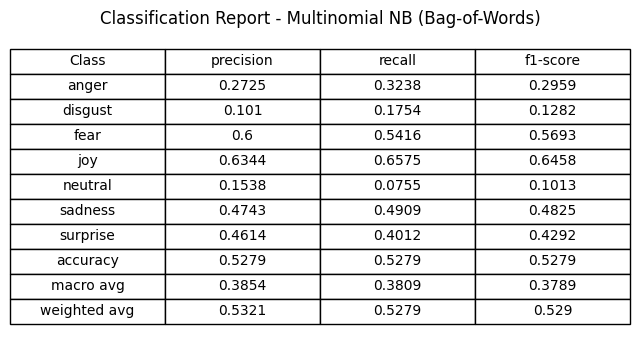

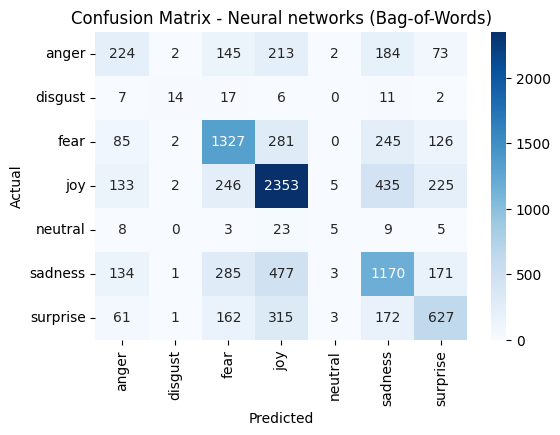

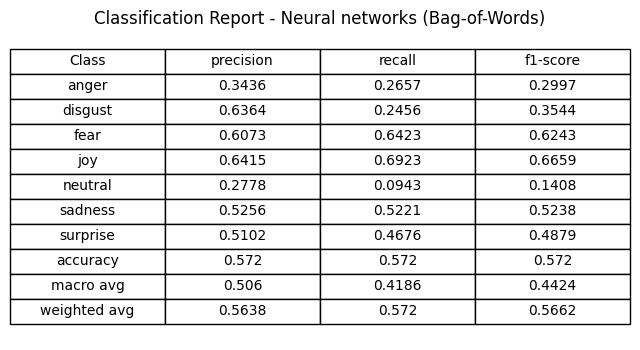

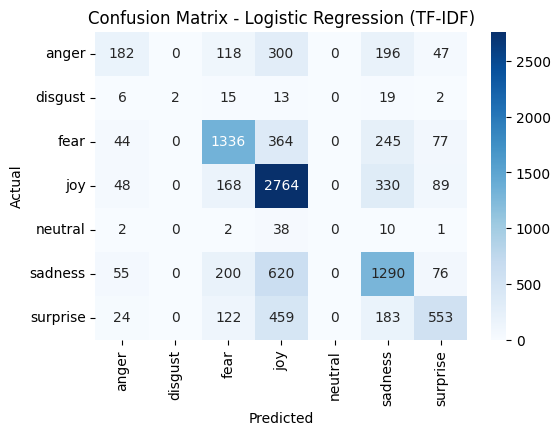

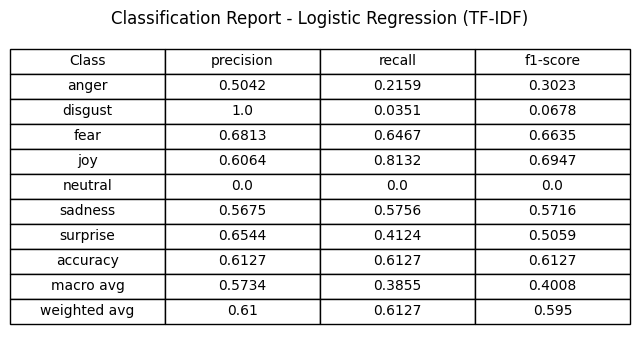

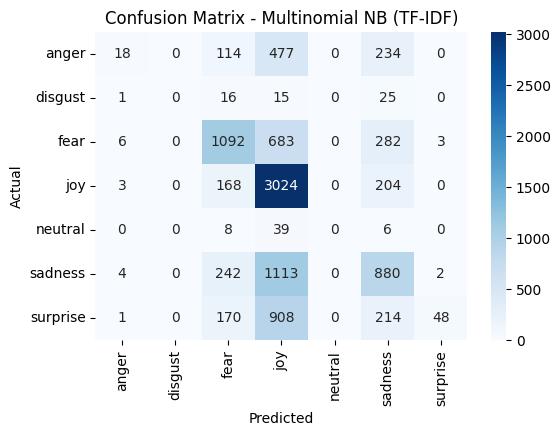

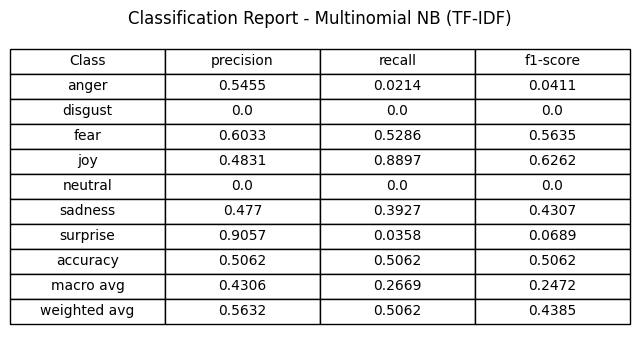

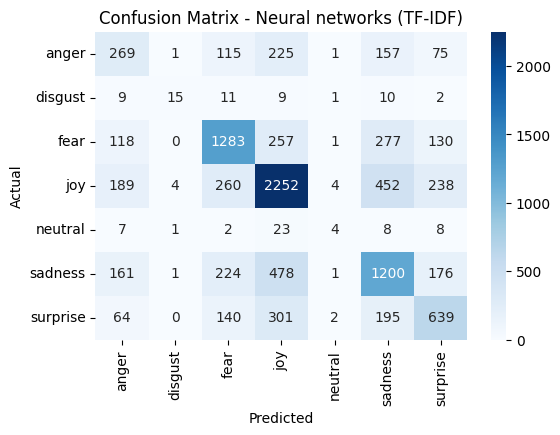

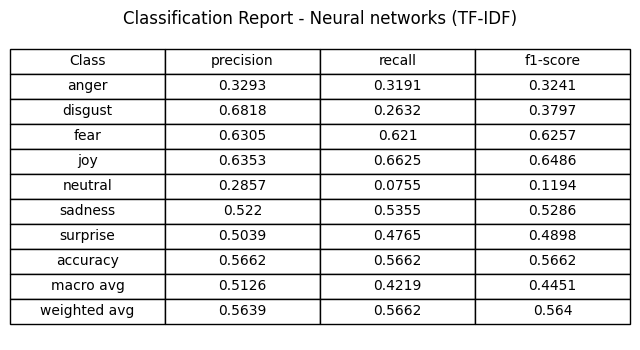

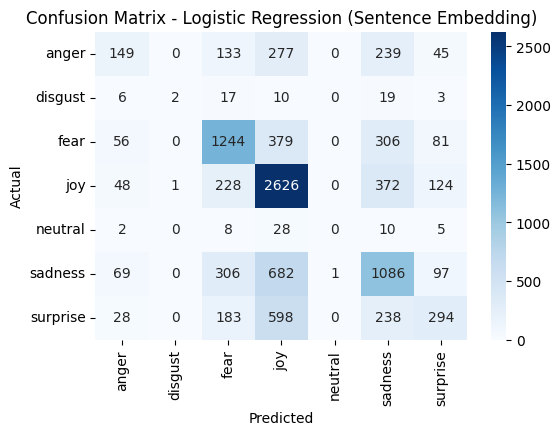

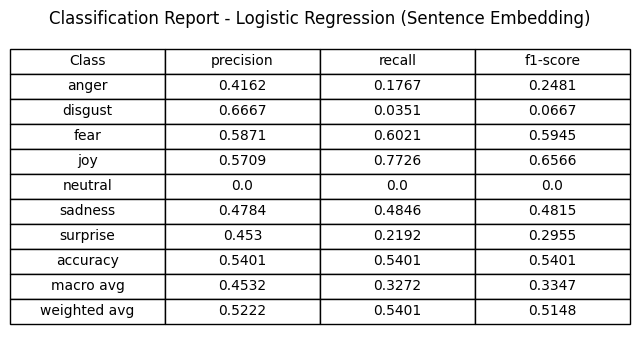

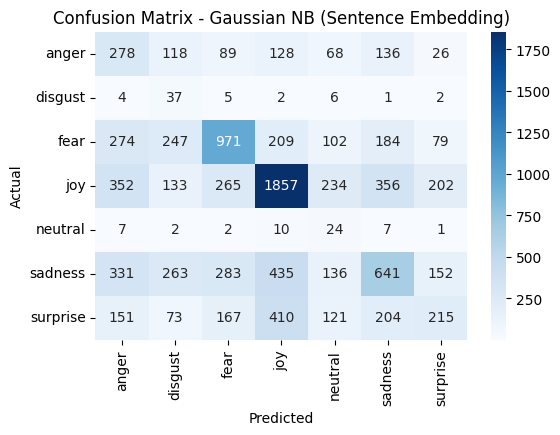

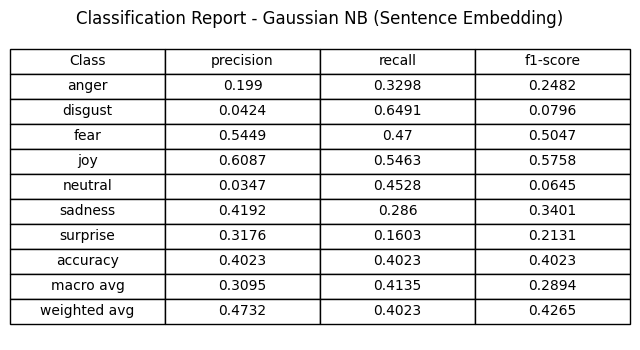

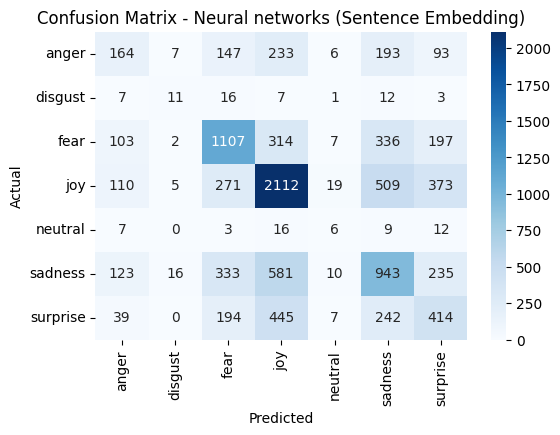

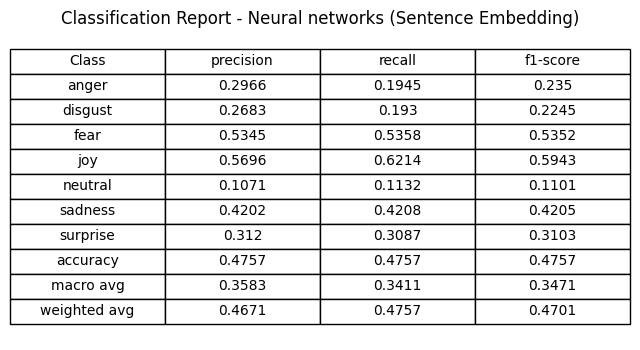

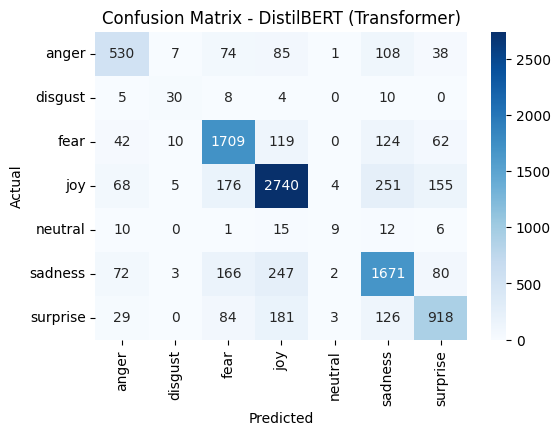

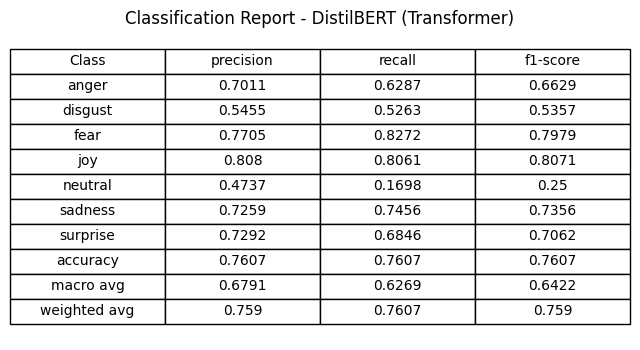

In [51]:
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

class_names = label_encoder.classes_

print("\nGenerating visualizations...")

plot_emotion_mapping_table()

for emb_name in results:
    for model_name in results[emb_name]:
        model_data = results[emb_name][model_name]
        plot_confusion_matrix(model_data["cm"], class_names, model_name, emb_name)
        plot_classification_report(model_data["report"], model_name, emb_name)

#plot_roc_curves(results, y_test)

print()


## Accuracy comparison

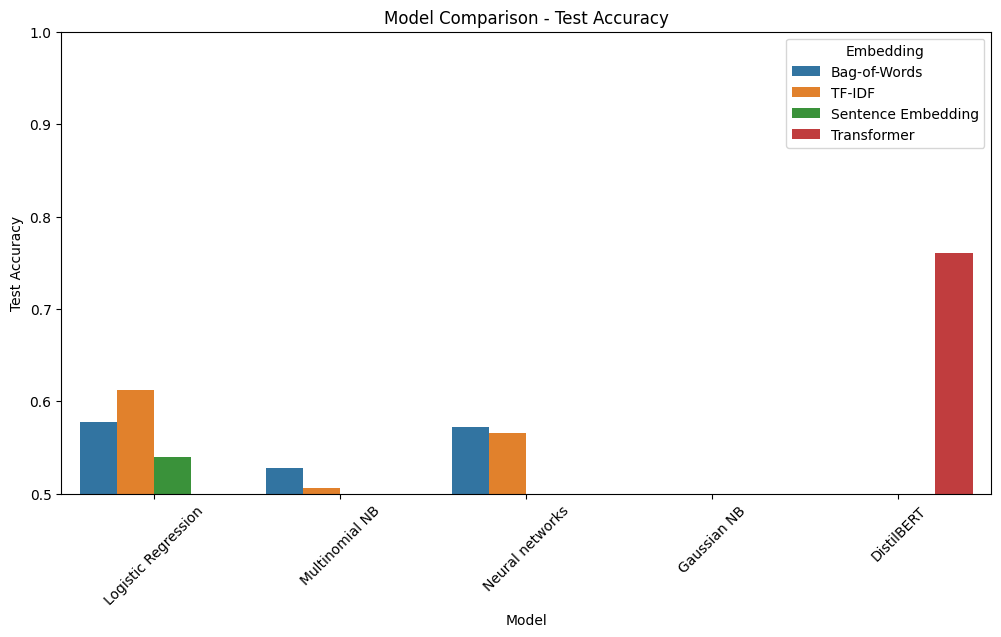


Final Test Accuracies:
            Embedding                Model  Test Accuracy
9         Transformer           DistilBERT         0.7607
3              TF-IDF  Logistic Regression         0.6127
0        Bag-of-Words  Logistic Regression         0.5775
2        Bag-of-Words      Neural networks         0.5720
5              TF-IDF      Neural networks         0.5662
6  Sentence Embedding  Logistic Regression         0.5401
1        Bag-of-Words       Multinomial NB         0.5279
4              TF-IDF       Multinomial NB         0.5062
8  Sentence Embedding      Neural networks         0.4757
7  Sentence Embedding          Gaussian NB         0.4023


In [52]:
acc_data = []
for emb_name in results:
    for model_name in results[emb_name]:
        acc_data.append({
            "Embedding": emb_name,
            "Model": model_name,
            "Test Accuracy": results[emb_name][model_name]["test_accuracy"]
        })

df_acc = pd.DataFrame(acc_data)

plt.figure(figsize=(12,6))
sns.barplot(data=df_acc, x="Model", y="Test Accuracy", hue="Embedding")
plt.title("Model Comparison - Test Accuracy")
plt.ylim(0.5, 1.0)
plt.xticks(rotation=45)
plt.show()

print("\nFinal Test Accuracies:")
print(df_acc.sort_values(by="Test Accuracy", ascending=False))